In [4]:
# [목적] 데이터셋 폴더에 어떤 파일/폴더가 있는지 전체 구조를 파악한다.
import os

base = '/home/kms/resnet_project/lidc-idri'

# 전체 폴더 구조 확인
for item in os.listdir(base):
    print(item)

LIDC-XML-only
manifest-1600709154662
slices_png
lidc-idri-nodule-counts-6-23-2015.xlsx
slices
checkpoints
labels.csv
tcia-diagnosis-data-2012-04-20.xls
nodule_malignancy_scores.json


In [2]:
# slices 폴더 안 환자 수 확인
# [목적] 전처리된 slices/ 폴더에 환자가 몇 명 있는지 확인한다.
slices_dir = f'{base}/slices'
patients = os.listdir(slices_dir)
print(f'환자 수: {len(patients)}')
print('환자 폴더 예시:', patients[:5])

환자 수: 889
환자 폴더 예시: ['LIDC-IDRI-0953', 'LIDC-IDRI-0549', 'LIDC-IDRI-0363', 'LIDC-IDRI-0155', 'LIDC-IDRI-0509']


In [3]:
# 환자 한 명의 파일 구조 확인
# [목적] 파일명 규칙(slice_{번호}_{악성도}.npy)을 확인한다.
# 이 규칙이 있어야 파일명에서 라벨을 뽑을 수 있음.
sample_patient = patients[0]
files = os.listdir(f'{slices_dir}/{sample_patient}')
print(f'{sample_patient} 안에 파일 수: {len(files)}')
print('파일 예시:', files[:10])

LIDC-IDRI-0953 안에 파일 수: 2
파일 예시: ['slice_048_4.npy', 'slice_047_4.npy']


이미지 shape: (300, 300)
픽셀값 범위: -3024.00 ~ 1403.00


/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


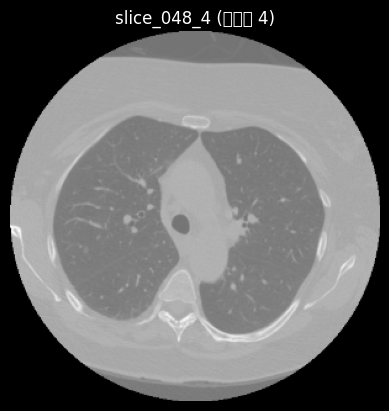

In [9]:
# [목적] npy 파일을 열어서 이미지 크기와 픽셀값 범위를 확인한다.
# HU 단위(-3024~1403)로 저장돼 있어서 클리핑+정규화가 필요함을 확인.
import numpy as np
import matplotlib.pyplot as plt

# npy 파일 하나 열어서 이미지 확인
sample_path = f'{slices_dir}/LIDC-IDRI-0953/slice_048_4.npy'
img = np.load(sample_path)

print(f'이미지 shape: {img.shape}')
print(f'픽셀값 범위: {img.min():.2f} ~ {img.max():.2f}')

plt.imshow(img, cmap='gray')
plt.title('slice_048_4 (악성도 4)')
plt.axis('off')
plt.show()

In [7]:
# labels.csv 확인
# [목적] prepare_csv.py로 생성된 labels.csv가 올바르게 만들어졌는지 확인한다.
# 총 슬라이스 수, 라벨 분포, train/val/test 분할 비율을 체크.
import pandas as pd

df = pd.read_csv(f'{base}/labels.csv')
print(df.shape)
print(df.head())
print('\n라벨 분포:')
print(df['label'].value_counts())
print('\nsplit 분포:')
print(df['split'].value_counts())

(5332, 6)
       patient_id                                         image_path  label  \
0  LIDC-IDRI-0953  /home/kms/resnet_project/lidc-idri/slices/LIDC...      1   
1  LIDC-IDRI-0953  /home/kms/resnet_project/lidc-idri/slices/LIDC...      1   
2  LIDC-IDRI-0549  /home/kms/resnet_project/lidc-idri/slices/LIDC...      1   
3  LIDC-IDRI-0549  /home/kms/resnet_project/lidc-idri/slices/LIDC...      1   
4  LIDC-IDRI-0549  /home/kms/resnet_project/lidc-idri/slices/LIDC...      0   

   split      cx      cy  
0  train   60.84  177.11  
1  train   60.90  176.90  
2    val  279.52  240.20  
3    val   97.33  207.78  
4    val   69.20  253.40  

라벨 분포:
label
1    3548
0    1784
Name: count, dtype: int64

split 분포:
split
train    3800
test      768
val       764
Name: count, dtype: int64


원본 범위: -3024.0 ~ 1403.0
전처리 후 범위: 0.000 ~ 1.000


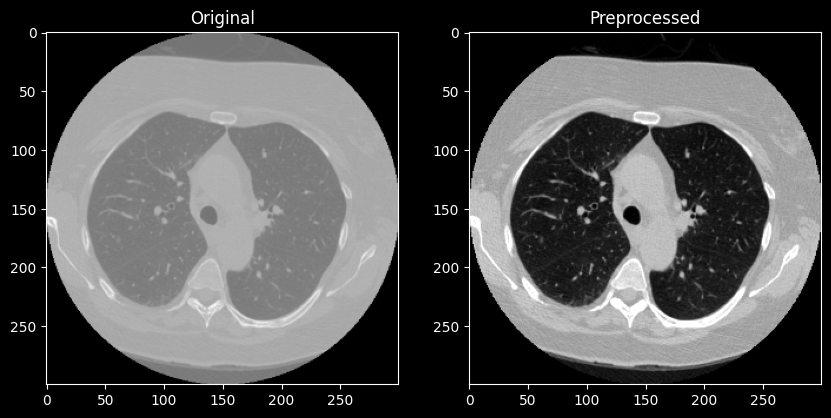

In [8]:
# 이미지 전처리 확인
# [목적] HU 클리핑(-1000~400)과 0~1 정규화 적용 전후를 시각적으로 비교한다.
# 전처리 후 결절이 더 잘 보이는지 확인하는 단계.

import numpy as np
import matplotlib.pyplot as plt

# HU 클리핑 + 정규화 확인
img = np.load('/home/kms/resnet_project/lidc-idri/slices/LIDC-IDRI-0953/slice_048_4.npy')

# 전처리
img_clipped = np.clip(img, -1000, 400)
img_norm = (img_clipped - (-1000)) / (400 - (-1000))  # 0~1 정규화

print(f'원본 범위: {img.min():.1f} ~ {img.max():.1f}')
print(f'전처리 후 범위: {img_norm.min():.3f} ~ {img_norm.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(img_norm, cmap='gray')
axes[1].set_title('Preprocessed')
plt.show()

In [3]:
# [목적] 원본 DICOM 파일을 읽어서 3D 볼륨 크기와 Spacing을 확인한다.
# Spacing이 환자마다 다르기 때문에 리샘플링(1x1x1mm)이 필요함을 확인.
import SimpleITK as sitk
import os

dicom_base = '/home/kms/resnet_project/lidc-idri/manifest-1600709154662/LIDC-IDRI'

# 환자 한 명 폴더 구조 확인
patient = 'LIDC-IDRI-0001'
patient_dir = f'{dicom_base}/{patient}'

for root, dirs, files in os.walk(patient_dir):
    dcm_files = [f for f in files if f.endswith('.dcm')]
    if dcm_files:
        print(f'폴더: {root}')
        print(f'dcm 파일 수: {len(dcm_files)}')
        break

# DICOM 읽어서 3D 볼륨 확인
reader = sitk.ImageSeriesReader()
series_IDs = reader.GetGDCMSeriesIDs(root)
print(f'시리즈 수: {len(series_IDs)}')

file_names = reader.GetGDCMSeriesFileNames(root, series_IDs[0])
reader.SetFileNames(file_names)
image = reader.Execute()

print(f'Volume shape: {image.GetSize()}')       # (X, Y, Z)
print(f'Spacing: {image.GetSpacing()}')          # (x_mm, y_mm, z_mm)
print(f'Origin: {image.GetOrigin()}')

폴더: /home/kms/resnet_project/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-35511/3000923.000000-NA-62357
dcm 파일 수: 2
시리즈 수: 1
Volume shape: (2022, 2022, 2)
Spacing: (1.0, 1.0, 1.0)
Origin: (0.0, 0.0, 0.0)


In [6]:
# [목적] 원본 DICOM 파일을 읽어서 3D 볼륨 크기와 Spacing을 확인한다.
# Spacing이 환자마다 다르기 때문에 리샘플링(1x1x1mm)이 필요함을 확인.
import SimpleITK as sitk
import os

dicom_base = '/home/kms/resnet_project/lidc-idri/manifest-1600709154662/LIDC-IDRI'

for patient in sorted(os.listdir(dicom_base)):
    patient_dir = f'{dicom_base}/{patient}'
    if not os.path.isdir(patient_dir):
        continue
    for root, dirs, files in os.walk(patient_dir):
        dcm_files = [f for f in files if f.endswith('.dcm')]
        if len(dcm_files) > 100:
            print(f'환자: {patient}')
            print(f'폴더: {root}')
            print(f'dcm 파일 수: {len(dcm_files)}')

            reader = sitk.ImageSeriesReader()
            series_IDs = reader.GetGDCMSeriesIDs(root)
            file_names = reader.GetGDCMSeriesFileNames(root, series_IDs[0])
            reader.SetFileNames(file_names)
            image = reader.Execute()

            print(f'Volume shape: {image.GetSize()}')
            print(f'Spacing: {image.GetSpacing()}')
            print('---')
            break
    else:
        continue
    break

환자: LIDC-IDRI-0001
폴더: /home/kms/resnet_project/lidc-idri/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192
dcm 파일 수: 133
Volume shape: (512, 512, 133)
Spacing: (0.703125, 0.703125, 2.5)
---


In [7]:
# [목적] 어노테이션 XML 파일이 몇 개 있는지 확인한다.
# XML에 채점자 점수, 결절 좌표가 들어있어서 필터링에 필요함.
xml_dir = '/home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml'
xml_files = []
for root, dirs, files in os.walk(xml_dir):
    for f in files:
        if f.endswith('.xml'):
            xml_files.append(os.path.join(root, f))

print(f'XML 파일 수: {len(xml_files)}')
print('예시:', xml_files[0])

XML 파일 수: 1318
예시: /home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml/189/165.xml


In [8]:
# XML 하나 열어서 구조 확인
# [목적] XML 파일 구조와 네임스페이스를 확인한다.
# readingSession이 채점자 1명분 데이터이고, 4개면 4명이 채점한 것.

import xml.etree.ElementTree as ET

xml_path = '/home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml/189/165.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# 네임스페이스 확인
print(root.tag)
print(root.attrib)

# 전체 구조 앞부분만 출력
for i, child in enumerate(root):
    print(child.tag)
    if i > 5:
        break

{http://www.nih.gov}LidcReadMessage
{'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.1307390736878.0', '{http://www.w3.org/2001/XMLSchema-instance}schemaLocation': 'http://www.nih.gov  http://troll.rad.med.umich.edu/lidc/LidcReadMessage.xsd'}
{http://www.nih.gov}ResponseHeader
{http://www.nih.gov}readingSession
{http://www.nih.gov}readingSession
{http://www.nih.gov}readingSession
{http://www.nih.gov}readingSession


In [9]:
# 결절 정보 확인
# [목적] XML 파일 구조와 네임스페이스를 확인한다.
# readingSession이 채점자 1명분 데이터이고, 4개면 4명이 채점한 것.
ns = {'ns': 'http://www.nih.gov'}

sessions = root.findall('.//ns:readingSession', ns)
print(f'채점자 수: {len(sessions)}')

# 첫 번째 채점자의 첫 번째 결절 확인
for nodule in sessions[0].findall('ns:unblindedReadNodule', ns):
    nid = nodule.find('ns:noduleID', ns).text
    char = nodule.find('ns:characteristics', ns)
    if char is not None:
        mal = char.find('ns:malignancy', ns)
        if mal is not None:
            print(f'결절ID: {nid}, 악성도: {mal.text}')
    break

채점자 수: 4
결절ID: 6272, 악성도: 4


In [10]:
# [목적] noduleID로 결절을 묶으면 왜 안 되는지 확인한다.
# LIDC-IDRI는 채점자마다 같은 결절에 다른 ID를 부여해서
# ID로 묶으면 채점자가 항상 1명으로 나옴 → 위치 기반 매칭 필요.
import xml.etree.ElementTree as ET
from statistics import variance, mean

ns = {'ns': 'http://www.nih.gov'}

xml_path = '/home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml/189/165.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

sessions = root.findall('.//ns:readingSession', ns)

nodule_scores = {}
for session in sessions:
    for nodule in session.findall('ns:unblindedReadNodule', ns):
        nid = nodule.find('ns:noduleID', ns).text
        char = nodule.find('ns:characteristics', ns)
        if char is not None:
            mal = char.find('ns:malignancy', ns)
            if mal is not None and mal.text is not None:
                if nid not in nodule_scores:
                    nodule_scores[nid] = []
                nodule_scores[nid].append(int(mal.text))

for nid, scores in nodule_scores.items():
    n = len(scores)
    avg = mean(scores)
    var = variance(scores) if n >= 2 else 0

    exclude = False
    reason = ''
    if n < 3:
        exclude = True
        reason = f'채점자 {n}명'
    elif var > 1:
        exclude = True
        reason = f'분산 {var:.2f}'
    elif 2.5 <= avg <= 3.5:
        exclude = True
        reason = f'평균 {avg:.2f}'

    status = '제외' if exclude else '포함'
    print(f'결절 {nid}: 점수{scores}, 평균{avg:.1f}, 분산{var:.2f}, 채점자{n}명 → {status} ({reason})')

결절 6272: 점수[4], 평균4.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)
결절 IL057_69743: 점수[4], 평균4.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)
결절 IL057_69744: 점수[3], 평균3.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)
결절 Nodule 001: 점수[5], 평균5.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)
결절 4900: 점수[3], 평균3.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)


In [11]:
# [목적] ID 대신 결절의 공간 좌표(x, y, z)로 어노테이션을 수집한다.
# 다음 단계에서 좌표가 가까운 결절들을 같은 결절로 묶기 위한 준비.
import xml.etree.ElementTree as ET
import numpy as np
from statistics import variance, mean

ns = {'ns': 'http://www.nih.gov'}

xml_path = '/home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml/189/165.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

sessions = root.findall('.//ns:readingSession', ns)

# 채점자별 결절 수집 (위치 + 점수)
all_nodules = []  # [(reader_idx, score, centroid_z, centroid_x, centroid_y)]

for reader_idx, session in enumerate(sessions):
    for nodule in session.findall('ns:unblindedReadNodule', ns):
        char = nodule.find('ns:characteristics', ns)
        if char is None:
            continue
        mal = char.find('ns:malignancy', ns)
        if mal is None or mal.text is None:
            continue
        score = int(mal.text)

        # ROI 좌표 수집
        rois = nodule.findall('ns:roi', ns)
        if not rois:
            continue

        z_positions = []
        xy_points = []
        for roi in rois:
            z = roi.find('ns:imageZposition', ns)
            if z is not None:
                z_positions.append(float(z.text))
            for edge in roi.findall('ns:edgeMap', ns):
                x = float(edge.find('ns:xCoord', ns).text)
                y = float(edge.find('ns:yCoord', ns).text)
                xy_points.append([x, y])

        if xy_points:
            cx = np.mean([p[0] for p in xy_points])
            cy = np.mean([p[1] for p in xy_points])
            cz = np.mean(z_positions) if z_positions else 0
            all_nodules.append((reader_idx, score, cz, cx, cy))

print(f'전체 결절 어노테이션 수: {len(all_nodules)}')
for n in all_nodules:
    print(f'  reader{n[0]}, score={n[1]}, z={n[2]:.1f}, x={n[3]:.1f}, y={n[4]:.1f}')

전체 결절 어노테이션 수: 5
  reader0, score=4, z=-193.6, x=191.4, y=407.7
  reader1, score=4, z=-193.6, x=190.8, y=408.1
  reader1, score=3, z=-63.4, x=366.5, y=321.5
  reader2, score=5, z=-193.6, x=190.2, y=407.6
  reader3, score=3, z=-192.9, x=191.0, y=408.7


In [12]:
# [목적] 좌표가 가까운 결절들을 같은 결절로 묶고(그룹핑),
# 팀이 정한 필터링 조건 3가지를 적용한다.
#   1) 채점자 3명 미만 제외 → 신뢰도 낮은 어노테이션 제거
#   2) 점수 분산 > 1 제외  → 채점자 간 의견 불일치가 큰 결절 제거
#   3) 평균 2.5~3.5 제외  → 양성/악성 경계가 애매한 결절 제거
# 통과한 결절만 학습 데이터로 사용하고, 중심좌표와 라벨을 출력한다.
from scipy.spatial.distance import euclidean

# 위치 기반 결절 그룹핑 (거리 10픽셀 이내 = 같은 결절)
groups = []
used = [False] * len(all_nodules)

for i, n1 in enumerate(all_nodules):
    if used[i]:
        continue
    group = [n1]
    used[i] = True
    for j, n2 in enumerate(all_nodules):
        if used[j] or i == j:
            continue
        dist = euclidean([n1[2], n1[3], n1[4]], [n2[2], n2[3], n2[4]])
        if dist < 15:  # 15 이내면 같은 결절
            group.append(n2)
            used[j] = True
    groups.append(group)

# 그룹별 필터링
print(f'결절 그룹 수: {len(groups)}')
for i, group in enumerate(groups):
    scores = [n[1] for n in group]
    n_readers = len(group)
    avg = mean(scores)
    var = variance(scores) if n_readers >= 2 else 0

    exclude = False
    reason = ''
    if n_readers < 3:
        exclude = True
        reason = f'채점자 {n_readers}명'
    elif var > 1:
        exclude = True
        reason = f'분산 {var:.2f}'
    elif 2.5 <= avg <= 3.5:
        exclude = True
        reason = f'평균 {avg:.2f}'

    cx = np.mean([n[3] for n in group])
    cy = np.mean([n[4] for n in group])
    cz = np.mean([n[2] for n in group])

    status = '제외' if exclude else '포함'
    label = 0 if avg <= 2 else 1
    print(f'결절{i+1}: 점수{scores}, 평균{avg:.1f}, 분산{var:.2f}, 채점자{n_readers}명 → {status} ({reason})')
    if not exclude:
        print(f'  → 라벨:{label}, 중심좌표 x={cx:.1f}, y={cy:.1f}, z={cz:.1f}')

결절 그룹 수: 2
결절1: 점수[4, 4, 5, 3], 평균4.0, 분산0.67, 채점자4명 → 포함 ()
  → 라벨:1, 중심좌표 x=190.8, y=408.0, z=-193.4
결절2: 점수[3], 평균3.0, 분산0.00, 채점자1명 → 제외 (채점자 1명)


In [13]:
# [목적] 전체 XML 파일을 순회하면서 필터링 조건을 통과한 결절만 수집한다.
# 결절별로 중심좌표(x, y, z), 라벨, 환자ID를 추출해서
# 나중에 DICOM에서 3D ROI를 잘라낼 때 사용할 정보를 만든다.

import xml.etree.ElementTree as ET
import numpy as np
from statistics import variance, mean
from scipy.spatial.distance import euclidean
import os
import pandas as pd

ns = {'ns': 'http://www.nih.gov'}
xml_dir = '/home/kms/resnet_project/lidc-idri/LIDC-XML-only/tcia-lidc-xml'

def parse_xml_nodules(xml_path):
    """XML 하나에서 필터링 통과한 결절 목록 반환"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except:
        return [], None

    # SeriesInstanceUID → 환자 매칭에 사용
    header = root.find('.//ns:ResponseHeader', ns)
    uid = header.find('ns:SeriesInstanceUid', ns).text if header is not None else None

    sessions = root.findall('.//ns:readingSession', ns)

    # 채점자별 결절 수집
    all_nodules = []
    for reader_idx, session in enumerate(sessions):
        for nodule in session.findall('ns:unblindedReadNodule', ns):
            char = nodule.find('ns:characteristics', ns)
            if char is None:
                continue
            mal = char.find('ns:malignancy', ns)
            if mal is None or mal.text is None:
                continue
            score = int(mal.text)

            rois = nodule.findall('ns:roi', ns)
            if not rois:
                continue

            z_positions = []
            xy_points = []
            for roi in rois:
                z = roi.find('ns:imageZposition', ns)
                if z is not None:
                    z_positions.append(float(z.text))
                for edge in roi.findall('ns:edgeMap', ns):
                    x = float(edge.find('ns:xCoord', ns).text)
                    y = float(edge.find('ns:yCoord', ns).text)
                    xy_points.append([x, y])

            if xy_points:
                cx = np.mean([p[0] for p in xy_points])
                cy = np.mean([p[1] for p in xy_points])
                cz = np.mean(z_positions) if z_positions else 0
                all_nodules.append((reader_idx, score, cz, cx, cy))

    # 위치 기반 그룹핑
    groups = []
    used = [False] * len(all_nodules)
    for i, n1 in enumerate(all_nodules):
        if used[i]:
            continue
        group = [n1]
        used[i] = True
        for j, n2 in enumerate(all_nodules):
            if used[j] or i == j:
                continue
            if euclidean([n1[2], n1[3], n1[4]], [n2[2], n2[3], n2[4]]) < 15:
                group.append(n2)
                used[j] = True
        groups.append(group)

    # 필터링
    valid_nodules = []
    for group in groups:
        scores = [n[1] for n in group]
        n_readers = len(group)
        avg = mean(scores)
        var = variance(scores) if n_readers >= 2 else 0

        if n_readers < 3:
            continue
        if var > 1:
            continue
        if 2.5 <= avg <= 3.5:
            continue

        cx = np.mean([n[3] for n in group])
        cy = np.mean([n[4] for n in group])
        cz = np.mean([n[2] for n in group])
        label = 0 if avg <= 2 else 1

        valid_nodules.append({
            'uid': uid,
            'cx': round(cx, 2),
            'cy': round(cy, 2),
            'cz': round(cz, 2),
            'label': label,
            'n_readers': n_readers,
            'mean_score': round(avg, 2),
            'variance': round(var, 2)
        })

    return valid_nodules, uid

# 전체 XML 순회
all_valid = []
xml_files = []
for root_dir, dirs, files in os.walk(xml_dir):
    for f in files:
        if f.endswith('.xml'):
            xml_files.append(os.path.join(root_dir, f))

print(f'전체 XML: {len(xml_files)}개 처리 시작...')
for i, xml_path in enumerate(xml_files):
    nodules, uid = parse_xml_nodules(xml_path)
    all_valid.extend(nodules)
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(xml_files)} 처리 완료, 유효 결절: {len(all_valid)}개')

print(f'\n최종 유효 결절 수: {len(all_valid)}개')
df = pd.DataFrame(all_valid)
print(df['label'].value_counts())
print(df.head())

전체 XML: 1318개 처리 시작...
  100/1318 처리 완료, 유효 결절: 54개
  200/1318 처리 완료, 유효 결절: 95개
  300/1318 처리 완료, 유효 결절: 134개
  400/1318 처리 완료, 유효 결절: 179개
  500/1318 처리 완료, 유효 결절: 221개
  600/1318 처리 완료, 유효 결절: 242개
  700/1318 처리 완료, 유효 결절: 265개
  800/1318 처리 완료, 유효 결절: 292개
  900/1318 처리 완료, 유효 결절: 323개
  1000/1318 처리 완료, 유효 결절: 358개
  1100/1318 처리 완료, 유효 결절: 404개
  1200/1318 처리 완료, 유효 결절: 469개
  1300/1318 처리 완료, 유효 결절: 510개

최종 유효 결절 수: 515개
label
1    313
0    202
Name: count, dtype: int64
                                                 uid      cx      cy      cz  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.670107649586...  190.84  408.02 -193.42   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251...  330.84  192.67  -95.84   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.134370886216...  172.16  382.61 -227.75   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.134370886216...  166.44  307.58  -59.22   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331...  333.29  328.02 -102.08   

   label  n_readers  mean_score  var

In [14]:
# [목적] metadata.csv에서 Series UID → 환자ID(Subject ID) 매핑을 만든다.
# XML에서 추출한 uid로 어떤 환자의 DICOM 폴더를 읽어야 하는지 찾기 위함.

import pandas as pd

metadata_path = '/home/kms/resnet_project/lidc-idri/manifest-1600709154662/metadata.csv'
meta = pd.read_csv(metadata_path)
print(meta.columns.tolist())
print(meta.head(3))

['Series UID', 'Collection', '3rd Party Analysis', 'Data Description URI', 'Subject ID', 'Study UID', 'Study Description', 'Study Date', 'Series Description', 'Manufacturer', 'Modality', 'SOP Class Name', 'SOP Class UID', 'Number of Images', 'File Size', 'File Location', 'Download Timestamp']
                                          Series UID Collection  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...  LIDC-IDRI   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...  LIDC-IDRI   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...  LIDC-IDRI   

   3rd Party Analysis                           Data Description URI  \
0                 NaN  https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX   
1                 NaN  https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX   
2                 NaN  https://doi.org/10.7937/K9/TCIA.2015.LO9QL9SX   

       Subject ID                                          Study UID  \
0  LIDC-IDRI-0002  1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...   
1  L

In [15]:
# [목적] XML에서 추출한 uid(Series UID)를 metadata.csv와 매칭해서
# 환자ID(Subject ID)와 DICOM 폴더 경로(File Location)를 붙인다.
# 이 정보가 있어야 나중에 DICOM을 읽어서 3D ROI를 추출할 수 있음.

dicom_base = '/home/kms/resnet_project/lidc-idri/manifest-1600709154662'

# uid → 환자ID, 폴더경로 딕셔너리 생성
uid_to_info = {}
for _, row in meta.iterrows():
    uid_to_info[row['Series UID']] = {
        'subject_id': row['Subject ID'],
        'file_location': row['File Location'].replace('\\', '/')
    }

# df에 환자ID, DICOM 경로 추가
df['subject_id'] = df['uid'].map(lambda x: uid_to_info.get(x, {}).get('subject_id'))
df['dicom_dir'] = df['uid'].map(
    lambda x: f"{dicom_base}/{uid_to_info.get(x, {}).get('file_location', '')}"
    if x in uid_to_info else None
)

# 매칭 결과 확인
print(f'전체 결절: {len(df)}개')
print(f'환자ID 매칭 성공: {df["subject_id"].notna().sum()}개')
print(f'환자ID 매칭 실패: {df["subject_id"].isna().sum()}개')
print(df[['subject_id', 'dicom_dir', 'label', 'cx', 'cy', 'cz']].head(3))

전체 결절: 515개
환자ID 매칭 성공: 515개
환자ID 매칭 실패: 0개
       subject_id                                          dicom_dir  label  \
0  LIDC-IDRI-0645  /home/kms/resnet_project/lidc-idri/manifest-16...      1   
1  LIDC-IDRI-0697  /home/kms/resnet_project/lidc-idri/manifest-16...      1   
2  LIDC-IDRI-0788  /home/kms/resnet_project/lidc-idri/manifest-16...      1   

       cx      cy      cz  
0  190.84  408.02 -193.42  
1  330.84  192.67  -95.84  
2  172.16  382.61 -227.75  


In [16]:
# [목적] 결절 하나를 실제로 DICOM에서 읽어서 3D ROI를 잘라낸다.
# 결절 중심좌표(cx, cy, cz)를 기준으로 ±32 voxel 큐브를 추출하는 과정을 검증.
# 이 과정이 정상 작동하면 전체 515개에 적용할 수 있음.

import SimpleITK as sitk
import numpy as np

# 첫 번째 결절로 테스트
row = df.iloc[0]
print(f'환자: {row["subject_id"]}')
print(f'DICOM 경로: {row["dicom_dir"]}')
print(f'결절 중심: cx={row["cx"]}, cy={row["cy"]}, cz={row["cz"]}')
print(f'라벨: {row["label"]}')

# DICOM 읽기
reader = sitk.ImageSeriesReader()
series_IDs = reader.GetGDCMSeriesIDs(row['dicom_dir'])
file_names = reader.GetGDCMSeriesFileNames(row['dicom_dir'], series_IDs[0])
reader.SetFileNames(file_names)
image = reader.Execute()

print(f'\nVolume shape: {image.GetSize()}')
print(f'Spacing: {image.GetSpacing()}')
print(f'Origin: {image.GetOrigin()}')

환자: LIDC-IDRI-0645
DICOM 경로: /home/kms/resnet_project/lidc-idri/manifest-1600709154662/./LIDC-IDRI/LIDC-IDRI-0645/01-01-2000-NA-CT LUNG SCREEN-53655/NA-87713
결절 중심: cx=190.84, cy=408.02, cz=-193.42
라벨: 1

Volume shape: (512, 512, 240)
Spacing: (0.585938, 0.585938, 1.2500000460251046)
Origin: (-139.100006, -150.0, -329.200012)


In [17]:
# [목적] DICOM 볼륨을 1x1x1mm로 리샘플링한 뒤,
# 결절 중심좌표(cx, cy, cz)를 voxel 좌표로 변환하고
# ±32 voxel 큐브(64x64x64)를 잘라낸다.
# 이 큐브가 3D 모델의 입력 데이터가 됨.

import SimpleITK as sitk
import numpy as np

def resample_to_1mm(image):
    # 원본 spacing → 1x1x1mm로 리샘플링
    original_spacing = image.GetSpacing()
    original_size = image.GetSize()
    new_size = [
        int(round(original_size[i] * original_spacing[i]))
        for i in range(3)
    ]
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing([1.0, 1.0, 1.0])
    resample.SetSize(new_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(-1000)
    resample.SetInterpolator(sitk.sitkLinear)
    return resample.Execute(image)

def extract_roi(image, cx, cy, cz, half=32):
    # world 좌표(mm) → voxel 좌표(index) 변환
    voxel = image.TransformPhysicalPointToIndex((cx, cy, cz))
    vx, vy, vz = voxel

    size = image.GetSize()  # (X, Y, Z)

    # 경계 체크
    x1 = max(0, vx - half)
    x2 = min(size[0], vx + half)
    y1 = max(0, vy - half)
    y2 = min(size[1], vy + half)
    z1 = max(0, vz - half)
    z2 = min(size[2], vz + half)

    # numpy 배열로 변환 후 크롭
    arr = sitk.GetArrayFromImage(image)  # shape: (Z, Y, X)
    roi = arr[z1:z2, y1:y2, x1:x2]

    # HU 클리핑 + 정규화
    roi = np.clip(roi, -1000, 400)
    roi = (roi - (-1000)) / (400 - (-1000))  # 0~1

    return roi, voxel

# 리샘플링
print('리샘플링 중...')
resampled = resample_to_1mm(image)
print(f'리샘플링 후 shape: {resampled.GetSize()}')

# ROI 추출
roi, voxel = extract_roi(resampled, row['cx'], row['cy'], row['cz'])
print(f'voxel 좌표: {voxel}')
print(f'ROI shape: {roi.shape}')
print(f'ROI 값 범위: {roi.min():.3f} ~ {roi.max():.3f}')

# 중간 슬라이스 시각화
import matplotlib.pyplot as plt
mid = roi.shape[0] // 2
plt.imshow(roi[mid], cmap='gray')
plt.title(f'ROI 중간 슬라이스 (label={row["label"]})')
plt.axis('off')
plt.show()

리샘플링 중...
리샘플링 후 shape: (300, 300, 300)
voxel 좌표: (330, 558, 136)
ROI shape: (64, 0, 2)


ValueError: zero-size array to reduction operation minimum which has no identity

In [18]:
# [목적] XML의 cx, cy는 픽셀 좌표이고 cz는 mm(world) 좌표라서
# 픽셀 → mm 변환 후 voxel 좌표로 바꿔야 한다.
# origin과 spacing을 이용해서 올바른 world 좌표로 변환한다.

def extract_roi_fixed(image, cx_pix, cy_pix, cz_mm, half=32):
    spacing = image.GetSpacing()   # (x_mm, y_mm, z_mm)
    origin = image.GetOrigin()     # (x0, y0, z0) in mm

    # 픽셀 좌표 → world 좌표(mm) 변환
    # XML의 cx, cy는 원본 DICOM 픽셀 좌표 → 원본 spacing으로 mm 변환
    # 리샘플링 후는 1mm spacing이므로 그냥 origin 기준으로 index 계산
    cx_mm = origin[0] + cx_pix * spacing[0]
    cy_mm = origin[1] + cy_pix * spacing[1]

    voxel = image.TransformPhysicalPointToIndex((cx_mm, cy_mm, cz_mm))
    vx, vy, vz = voxel

    print(f'world 좌표: ({cx_mm:.1f}, {cy_mm:.1f}, {cz_mm:.1f})')
    print(f'voxel 좌표: ({vx}, {vy}, {vz})')

    size = image.GetSize()
    print(f'volume size: {size}')

    x1 = max(0, vx - half)
    x2 = min(size[0], vx + half)
    y1 = max(0, vy - half)
    y2 = min(size[1], vy + half)
    z1 = max(0, vz - half)
    z2 = min(size[2], vz + half)

    arr = sitk.GetArrayFromImage(image)  # (Z, Y, X)
    roi = arr[z1:z2, y1:y2, x1:x2]

    roi = np.clip(roi, -1000, 400)
    roi = (roi - (-1000)) / (400 - (-1000))

    return roi, voxel

roi, voxel = extract_roi_fixed(resampled, row['cx'], row['cy'], row['cz'])
print(f'ROI shape: {roi.shape}')


world 좌표: (51.7, 258.0, -193.4)
voxel 좌표: (191, 408, 136)
volume size: (300, 300, 300)
ROI shape: (64, 0, 64)


In [19]:
# [목적] 리샘플링 전 원본 이미지에서 좌표 변환이 올바른지 확인한다.
# 원본 spacing과 origin 기준으로 world 좌표 → voxel 좌표를 계산해서
# 결절이 실제로 볼륨 안에 있는지 검증한다.

print('=== 원본 이미지 정보 ===')
print(f'Size: {image.GetSize()}')
print(f'Spacing: {image.GetSpacing()}')
print(f'Origin: {image.GetOrigin()}')
print(f'Direction: {image.GetDirection()}')

print('\n=== XML 좌표 ===')
print(f'cx={row["cx"]}, cy={row["cy"]}, cz={row["cz"]}')

# 원본에서 직접 변환
orig_spacing = image.GetSpacing()
orig_origin = image.GetOrigin()

cx_mm = orig_origin[0] + row['cx'] * orig_spacing[0]
cy_mm = orig_origin[1] + row['cy'] * orig_spacing[1]
cz_mm = row['cz']

print(f'\nworld 좌표(mm): ({cx_mm:.1f}, {cy_mm:.1f}, {cz_mm:.1f})')

voxel_orig = image.TransformPhysicalPointToIndex((cx_mm, cy_mm, cz_mm))
print(f'원본 voxel 좌표: {voxel_orig}')
print(f'원본 size: {image.GetSize()}')
print(f'범위 내 여부: x={0<=voxel_orig[0]<image.GetSize()[0]}, y={0<=voxel_orig[1]<image.GetSize()[1]}, z={0<=voxel_orig[2]<image.GetSize()[2]}')

=== 원본 이미지 정보 ===
Size: (512, 512, 240)
Spacing: (0.585938, 0.585938, 1.2500000460251046)
Origin: (-139.100006, -150.0, -329.200012)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

=== XML 좌표 ===
cx=190.84, cy=408.02, cz=-193.42

world 좌표(mm): (-27.3, 89.1, -193.4)
원본 voxel 좌표: (191, 408, 109)
원본 size: (512, 512, 240)
범위 내 여부: x=True, y=True, z=True


world 좌표: (-27.3, 89.1, -193.4)
리샘플링 후 voxel 좌표: (112, 239, 136)
리샘플링 후 size: (300, 300, 300)
범위 내 여부: x=True, y=True, z=True
ROI shape: (64, 64, 64)
ROI 값 범위: 0.000 ~ 1.000


/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kms/lib/python3.8/site-packages/IPython/core/

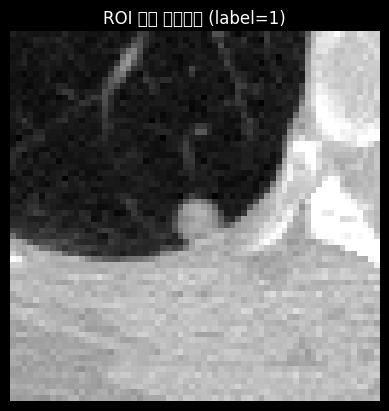

In [20]:
# [목적] XML의 cx, cy는 원본 픽셀 좌표이고 cz는 world 좌표(mm)다.
# 리샘플링 후 1mm spacing 기준으로 voxel 좌표를 올바르게 변환한다.
# 원본 spacing을 곱해서 mm로 바꾼 뒤 리샘플링된 이미지에서 index를 구한다.

def extract_roi_v2(orig_image, resampled_image, cx_pix, cy_pix, cz_mm, half=32):
    orig_spacing = orig_image.GetSpacing()
    orig_origin = orig_image.GetOrigin()

    # cx, cy: 픽셀 좌표 → world 좌표(mm)
    # origin은 더하는 게 아니라 TransformIndexToPhysicalPoint 써야 함
    cx_mm_world = orig_origin[0] + cx_pix * orig_spacing[0]
    cy_mm_world = orig_origin[1] + cy_pix * orig_spacing[1]

    print(f'world 좌표: ({cx_mm_world:.1f}, {cy_mm_world:.1f}, {cz_mm:.1f})')

    # 리샘플링된 이미지에서 voxel 좌표로 변환
    voxel = resampled_image.TransformPhysicalPointToIndex(
        (cx_mm_world, cy_mm_world, cz_mm)
    )
    vx, vy, vz = voxel
    print(f'리샘플링 후 voxel 좌표: ({vx}, {vy}, {vz})')

    size = resampled_image.GetSize()
    print(f'리샘플링 후 size: {size}')
    print(f'범위 내 여부: x={0<=vx<size[0]}, y={0<=vy<size[1]}, z={0<=vz<size[2]}')

    x1 = max(0, vx - half)
    x2 = min(size[0], vx + half)
    y1 = max(0, vy - half)
    y2 = min(size[1], vy + half)
    z1 = max(0, vz - half)
    z2 = min(size[2], vz + half)

    arr = sitk.GetArrayFromImage(resampled_image)  # (Z, Y, X)
    roi = arr[z1:z2, y1:y2, x1:x2]

    roi = np.clip(roi, -1000, 400)
    roi = (roi - (-1000)) / (400 - (-1000))

    return roi, voxel

roi, voxel = extract_roi_v2(image, resampled, row['cx'], row['cy'], row['cz'])
print(f'ROI shape: {roi.shape}')

if roi.size > 0:
    print(f'ROI 값 범위: {roi.min():.3f} ~ {roi.max():.3f}')
    import matplotlib.pyplot as plt
    mid = roi.shape[0] // 2
    plt.imshow(roi[mid], cmap='gray')
    plt.title(f'ROI 중간 슬라이스 (label={row["label"]})')
    plt.axis('off')
    plt.show()